In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

# List GPUs
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

# Check if TF was built with CUDA
print("Built with CUDA:", tf.test.is_built_with_cuda())

# Simple GPU operation test
with tf.device('/GPU:0'):
    a = tf.random.normal([1000, 1000])
    b = tf.matmul(a, a)
    print("GPU matmul successful:", b.shape)


TensorFlow version: 2.17.0
GPUs detected: []
Built with CUDA: False
GPU matmul successful: (1000, 1000)


In [2]:
import pandas as pd
import os

base_dir = "data"

# Load CSV
df = pd.read_csv(os.path.join(base_dir, "trainLabels.csv"))

# Add filename column
df["filename"] = df["image"].astype(str) + ".jpeg"

# Absolute path check
df["path"] = df["filename"].apply(
    lambda x: os.path.join(base_dir, "train", x)
)

# Remove missing images
df = df[df["path"].apply(os.path.exists)].copy()

print("Total images after validation:", len(df))
print(df.head())


Total images after validation: 35126
      image  level       filename                      path
0   10_left      0   10_left.jpeg   data\train\10_left.jpeg
1  10_right      0  10_right.jpeg  data\train\10_right.jpeg
2   13_left      0   13_left.jpeg   data\train\13_left.jpeg
3  13_right      0  13_right.jpeg  data\train\13_right.jpeg
4   15_left      1   15_left.jpeg   data\train\15_left.jpeg


In [3]:
from sklearn.model_selection import train_test_split

# Binary label
df["label"] = df["level"].apply(lambda x: 0 if x == 0 else 1)

# Check imbalance
print("Class distribution:")
print(df["label"].value_counts(normalize=True))

# Split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))


Class distribution:
label
0    0.734783
1    0.265217
Name: proportion, dtype: float64
Train size: 28100
Validation size: 7026


In [4]:
# Compute class weights manually
neg = (train_df["label"] == 0).sum()
pos = (train_df["label"] == 1).sum()
total = len(train_df)

weight_for_0 = total / (2 * neg)
weight_for_1 = total / (2 * pos)

print("Weight for Healthy (0):", weight_for_0)
print("Weight for Diseased (1):", weight_for_1)

# Assign sample weight per row
train_df["sample_weight"] = train_df["label"].apply(
    lambda x: weight_for_1 if x == 1 else weight_for_0
)

train_df[["label", "sample_weight"]].head()


Weight for Healthy (0): 0.6804862691916501
Weight for Diseased (1): 1.8851469207030727


,label,sample_weight
21764,0,0.680486
27803,0,0.680486
10937,0,0.680486
26887,1,1.885147
19614,1,1.885147


In [5]:
# Convert numeric labels to strings (required by Keras)
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)

train_df[["label", "sample_weight"]].head()


,label,sample_weight
21764,0,0.680486
27803,0,0.680486
10937,0,0.680486
26887,1,1.885147
19614,1,1.885147


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Training generator (with augmentation + weights)
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

# Validation generator (NO augmentation)
val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_gen.flow_from_dataframe(
    dataframe=train_df,
    directory=os.path.join(base_dir, "train"),
    x_col="filename",
    y_col="label",
    weight_col="sample_weight",   # ✅ THIS replaces class_weight
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_gen.flow_from_dataframe(
    dataframe=val_df,
    directory=os.path.join(base_dir, "train"),
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 28100 validated image filenames belonging to 2 classes.
Found 7026 validated image filenames belonging to 2 classes.


In [7]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def build_model():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze base model
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

model = build_model()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        patience=3,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15


C:\Anaconda\envs\project\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1093s 618ms/step - accuracy: 0.5897 - auc: 0.6067 - loss: 0.6780 - val_accuracy: 0.7378 - val_auc: 0.7133 - val_loss: 0.6144 - learning_rate: 0.0010
Epoch 2/15
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1060s 602ms/step - accuracy: 0.6509 - auc: 0.6607 - loss: 0.6482 - val_accuracy: 0.7486 - val_auc: 0.7148 - val_loss: 0.6013 - learning_rate: 0.0010
Epoch 3/15
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1051s 596ms/step - accuracy: 0.6613 - auc: 0.6766 - loss: 0.6391 - val_accuracy: 0.7518 - val_auc: 0.7082 - val_loss: 0.5720 - learning_rate: 0.0010
Epoch 4/15
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1041s 591ms/step - accuracy: 0.6803 - auc: 0.6897 - loss: 0.6311 - val_accuracy: 0.7032 - val_auc: 0.7203 - val_loss: 0.6144 - learning_rate: 0.0010
Epoch 5/15
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.6841 - auc: 0.6880 - loss: 0.6298
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 1027s 583ms/step - accuracy: 0.6841 

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels
y_true = val_generator.classes

# Predict probabilities
y_pred_probs = model.predict(val_generator, verbose=1)

# Convert probabilities → class labels
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Healthy", "Diseased"]))


440/440 ━━━━━━━━━━━━━━━━━━━━ 188s 424ms/step
Confusion Matrix:
 [[4299  864]
 [ 950  913]]

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.82      0.83      0.83      5163
    Diseased       0.51      0.49      0.50      1863

    accuracy                           0.74      7026
   macro avg       0.67      0.66      0.66      7026
weighted avg       0.74      0.74      0.74      7026



In [10]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prob = model.predict(img_array)[0][0]
    label = "Diseased" if prob >= 0.5 else "Healthy"

    plt.imshow(img)
    plt.title(f"Prediction: {label} (Prob: {prob:.2f})")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 892ms/step


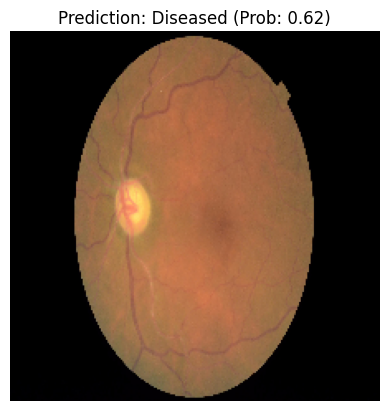

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


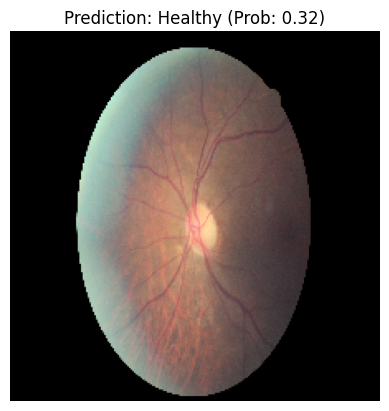

In [11]:
predict_image("data/train/15_left.jpeg")  # Diseased
predict_image("data/train/10_left.jpeg")  # Healthy


In [12]:
model.save("diabetic_retinopathy_model")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=diabetic_retinopathy_model.

In [16]:
model.save("diabetic_retinopathy_model.keras")

In [17]:
model = tf.keras.models.load_model("diabetic_retinopathy_model.keras")

C:\Anaconda\envs\project\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
import tensorflow as tf

model = tf.keras.models.load_model("diabetic_retinopathy_model.keras")
print("✅ Model loaded successfully")
model.summary()

✅ Model loaded successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 4,377,767 (16.70 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 164,099 (641.02 KB)

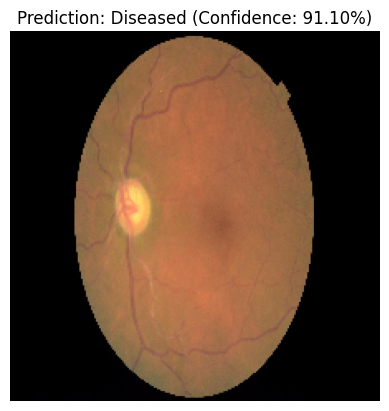

Raw prob : 0.9110
Label    : Diseased
Confidence: 91.10%


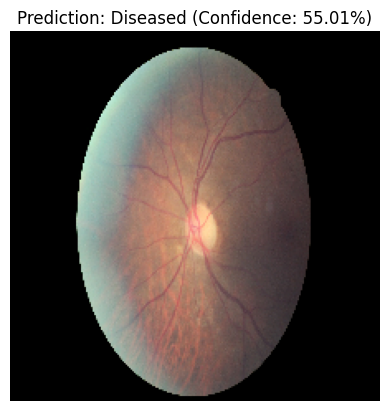

Raw prob : 0.5501
Label    : Diseased
Confidence: 55.01%


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    prob = model.predict(img_array, verbose=0)[0][0]  # verbose=0 hides progress bar
    label = "Diseased" if prob >= 0.5 else "Healthy"
    confidence = prob if prob >= 0.5 else 1 - prob    # cleaner confidence score

    plt.imshow(img)
    plt.title(f"Prediction: {label} (Confidence: {confidence:.2%})")  # shows 94.21% instead of 0.94
    plt.axis("off")
    plt.show()

    print(f"Raw prob : {prob:.4f}")
    print(f"Label    : {label}")
    print(f"Confidence: {confidence:.2%}")

# Test
predict_image("data/train/15_left.jpeg")  # Diseased
predict_image("data/train/10_left.jpeg")  # Healthy

✅ Model loaded successfully


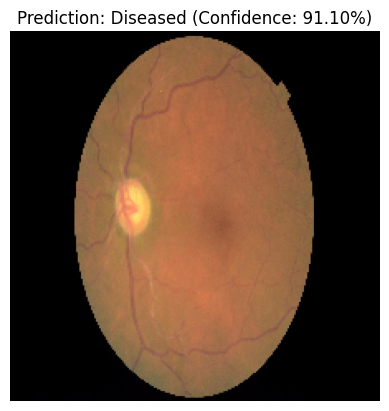

Raw prob  : 0.9110
Label     : Diseased
Confidence: 91.10%


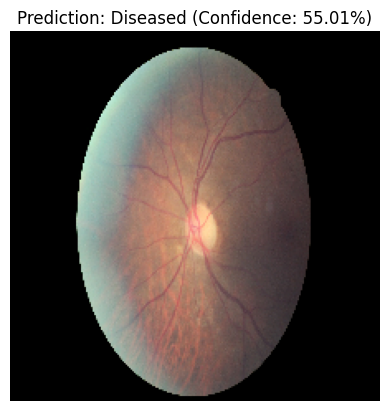

Raw prob  : 0.5501
Label     : Diseased
Confidence: 55.01%


In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# ✅ Load the saved model first
model = tf.keras.models.load_model("diabetic_retinopathy_model.keras")
print("✅ Model loaded successfully")

IMG_SIZE = (224, 224)

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    prob = model.predict(img_array, verbose=0)[0][0]
    label = "Diseased" if prob >= 0.5 else "Healthy"
    confidence = prob if prob >= 0.5 else 1 - prob

    plt.imshow(img)
    plt.title(f"Prediction: {label} (Confidence: {confidence:.2%})")
    plt.axis("off")
    plt.show()

    print(f"Raw prob  : {prob:.4f}")
    print(f"Label     : {label}")
    print(f"Confidence: {confidence:.2%}")

# Test
predict_image("data/train/15_left.jpeg")
predict_image("data/train/10_left.jpeg")